# 1.Data cleaning.



### IMPORT AND LOAD DATA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv("shopping_trends.csv")
print(df.head()) 


   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

### Check basic information

In [2]:
print(df.info())
print(df.describe())
print("Shape of dataset:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

### Check missing values


In [3]:
print(df.isnull().sum())


Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64


### clean and transform data

In [4]:
df= df.drop_duplicates()
df['Gender'] =df['Gender'].str.title()
##df['Date']=pd.to_datetime(df['Date'])

### Filter and analyze


In [5]:
##high_spenders= df[df[" Purchase Amount (USD)"]>100]
##print(high_spenders)

### Save clean data

In [6]:
df.to_csv("cleaned_shopping_trends.csv", index=False)

# 2.Eplaratory data analysis (EDA)

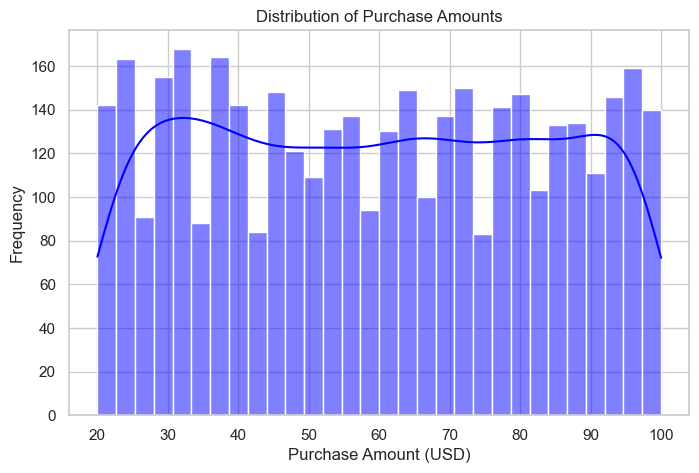

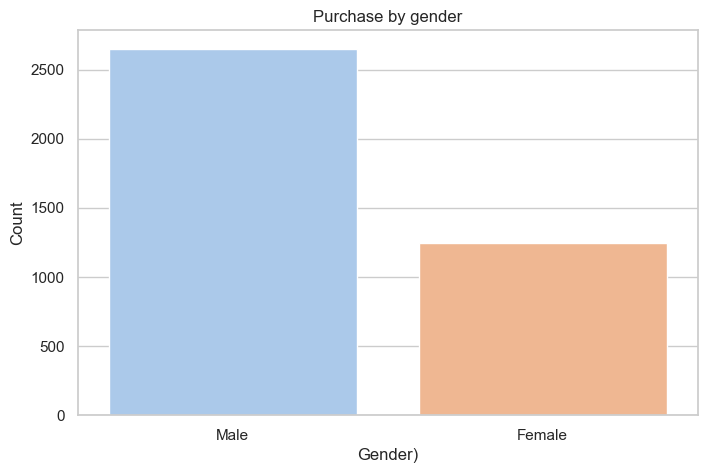

C:\Users\Tebeila\AppData\Local\Temp\ipykernel_22416\858624641.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='coolwarm',legend=False)


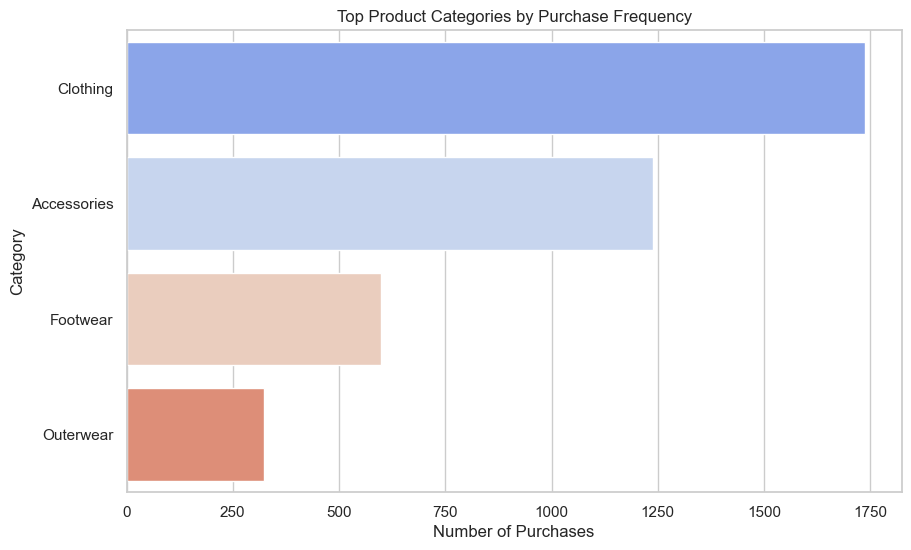

C:\Users\Tebeila\AppData\Local\Temp\ipykernel_22416\858624641.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette='viridis',legend=False)


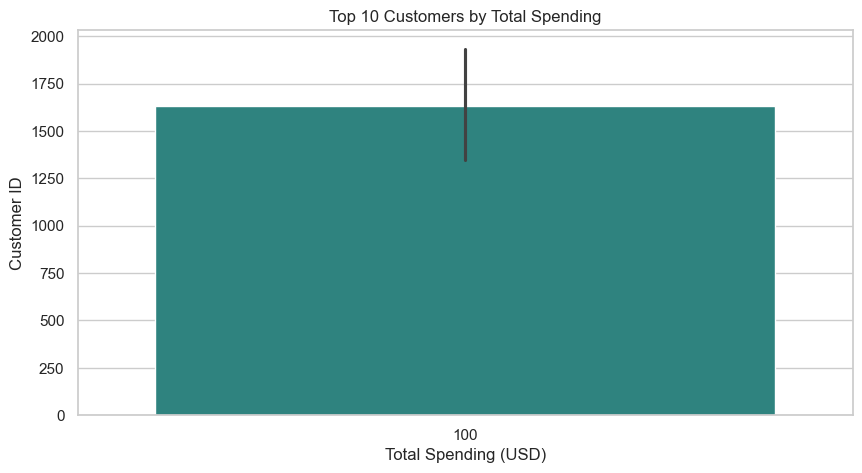

C:\Users\Tebeila\AppData\Local\Temp\ipykernel_22416\858624641.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Payment Method', y='Purchase Amount (USD)', data=df, palette='Set3' )


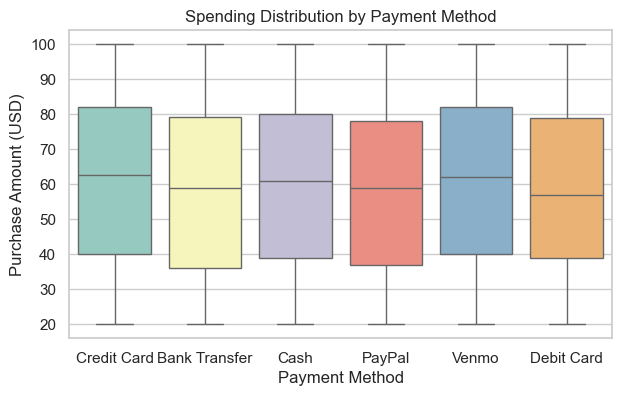

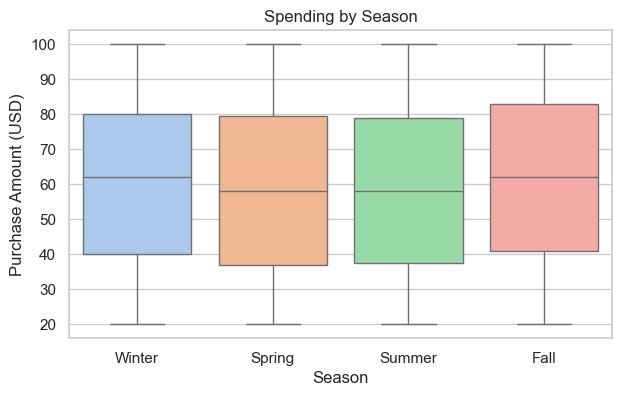

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5) 
plt.show()

# Distribution of Purchase Amounts
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase Amount (USD)'], bins=30, kde=True, color='blue')
plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency") # Shows how many people fall into the purchase amount category( e.g about 145 people spent 40usd)
plt.show()

# Purchases by gender
plt.figure(figsize=(8,5))
sns.countplot(x='Gender',hue= 'Gender', data=df, palette='pastel', legend=False)
plt.title("Purchase by gender")
plt.xlabel("Gender)")
plt.ylabel("Count") # Shows how many people fall into the purchase amount category( e.g about 145 people spent 40usd)
plt.show()

#Top Product Categories by Purchase Frequency
plt.figure(figsize=(10,6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='coolwarm',legend=False)
plt.title("Top Product Categories by Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.show()

#Top Customers by Total Spending
top_customers = df.groupby('Customer ID')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='viridis',legend=False)
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending (USD)")
plt.ylabel("Customer ID")
plt.show()

#Spending by Payment Method
plt.figure(figsize=(7,4))
sns.boxplot(x='Payment Method', y='Purchase Amount (USD)', data=df, palette='Set3' )
plt.title("Spending Distribution by Payment Method")
plt.show()

#Seasonal Spending Patterns
plt.figure(figsize=(7,4))
sns.boxplot(x='Season',hue='Season', y='Purchase Amount (USD)', data=df, palette='pastel',legend=False)
plt.title("Spending by Season")
plt.show()



### Correlation Between Numerical Variables

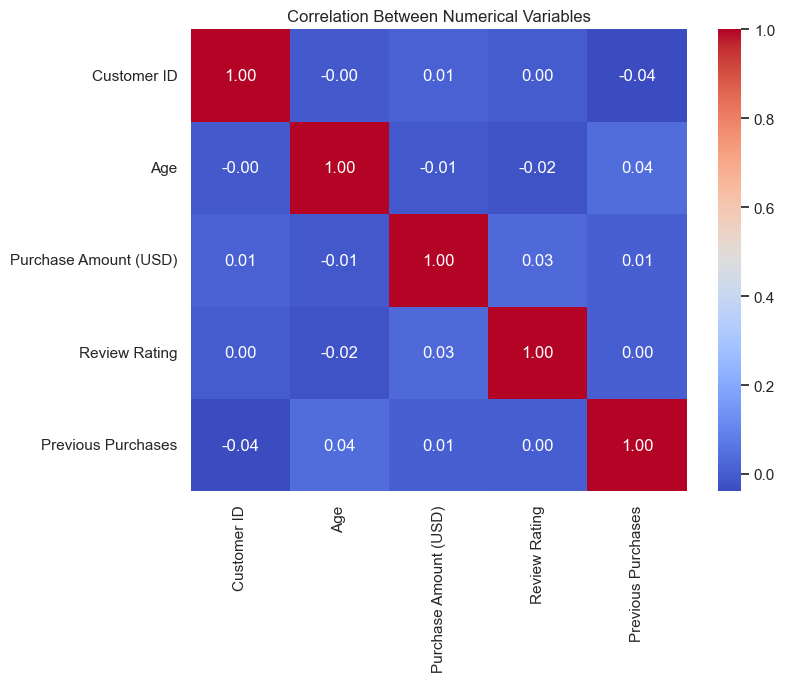

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numerical Variables")
plt.show()


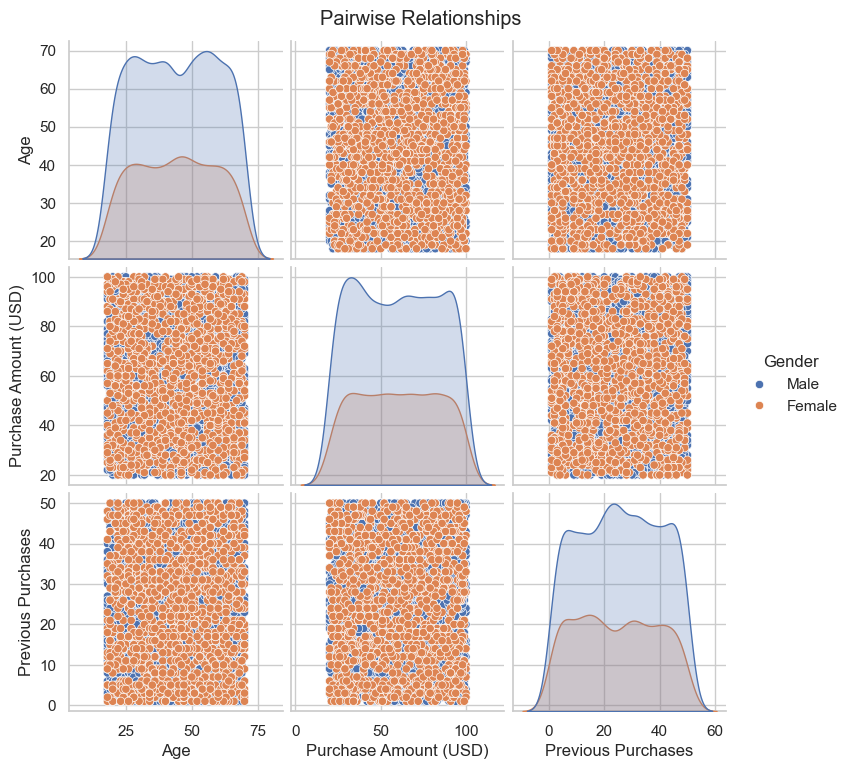

In [13]:
sns.pairplot(df, vars=['Age', 'Purchase Amount (USD)', 'Previous Purchases'], hue='Gender')
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()


# FEATURE ENGINEERING


In [15]:
df = df.drop(columns=['CustomerID'], errors='ignore')
df_encoded= pd.get_dummies(df, drop_first=True)

In [22]:

import numpy as np
df_encoded['Previous Purchases'] = np.log1p(df_encoded['Previous Purchases'])
df_encoded['Purchase Amount (USD)'] = np.log1p(df_encoded['Purchase Amount (USD)'])


In [23]:
#Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)


In [24]:
#Applying principal component analysis(PCA)
from sklearn.decomposition import PCA

pca = PCA().fit(scaled_data)
explained = np.cumsum(pca.explained_variance_ratio_)

# Applying PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9)  # keep 90% of variance
pca_data = pca.fit_transform(scaled_data)

print("Original shape:", scaled_data.shape)
print("Reduced shape:", pca_data.shape)


Original shape: (3900, 136)
Reduced shape: (3900, 107)


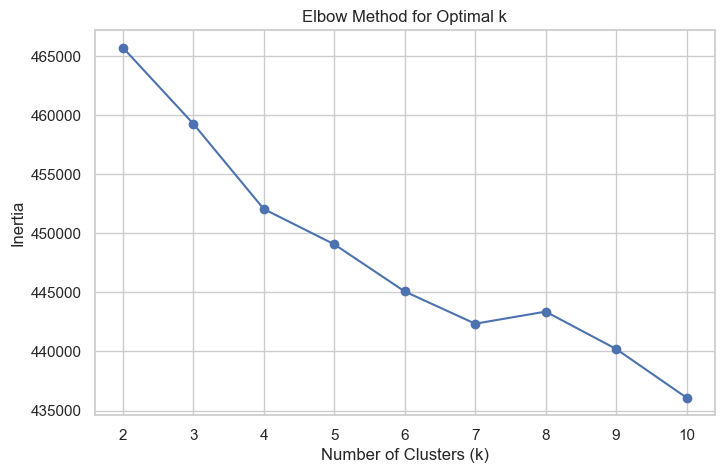

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Test different numbers of clusters
inertia = []  # sum of squared distances to cluster centers
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)  # or scaled_data if you skipped PCA
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


In [28]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data) ## tey pca data too!!
    score = silhouette_score(pca_data, labels)
    print(f"k={k}, silhouette score={score:.4f}")


k=2, silhouette score=0.0291
k=3, silhouette score=0.0293
k=4, silhouette score=0.0327
k=5, silhouette score=0.0248
k=6, silhouette score=0.0294
k=7, silhouette score=0.0274
k=8, silhouette score=0.0277
k=9, silhouette score=0.0297
k=10, silhouette score=0.0341


In [29]:
optimal_k = 4  # example
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to your original dataset
df['Cluster'] = clusters


In [31]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)


         Customer ID        Age  Purchase Amount (USD)  Review Rating  \
Cluster                                                                 
0        1959.759599  44.442404              60.255426       3.790651   
1        2782.477393  43.910159              60.496183       3.750029   
2         845.008634  44.042386              59.214286       3.731476   
3        1907.265432  44.311728              57.172840       3.746914   

         Previous Purchases  
Cluster                      
0                 25.232053  
1                 25.234880  
2                 25.664050  
3                 24.956790  


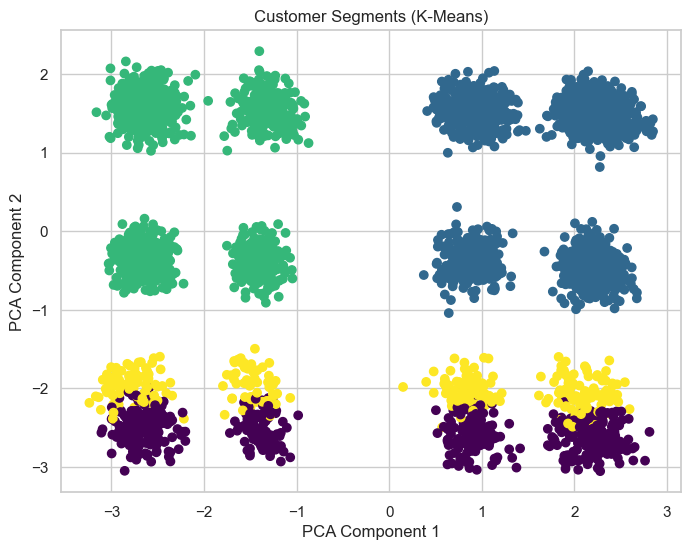

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.title('Customer Segments (K-Means)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [33]:
# Example mapping based on interpretation
cluster_labels = {
    0: 'High Spender',
    1: 'High Spender',
    2: 'Frequent Buyer',
    3: 'Low Spender'
}

# Assign labels
df['Customer Segment'] = df['Cluster'].map(cluster_labels)


In [34]:
df['Customer Segment'].value_counts()


Customer Segment
High Spender      2302
Frequent Buyer    1274
Low Spender        324
Name: count, dtype: int64

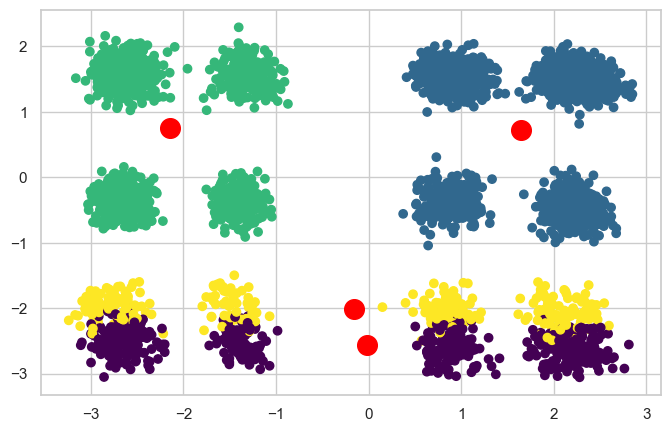

In [38]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans.labels_, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='o')

